# Combination of Numerical Model and Observations to Improve Machine Learning Predictions — Ensemble Training

**Objective:** Build and evaluate machine-learning emulators of the Lorenz system using attractor-covering ensemble trajectories, sparse noisy observations, and imperfect numerical-model data to assess how combining information sources impacts prediction skill.

## Why the Lorenz System?

The Lorenz system is a three-variable nonlinear dynamical system introduced by Edward N. Lorenz (1963):

- dx/dt = sigma (y - x)
- dy/dt = x (rho - z) - y
- dz/dt = xy - beta z

It is a classic chaotic system: tiny differences in initial conditions can lead to large differences in future trajectories.

It is used here as a **simple representation of a climate system** because it captures key ideas relevant to climate prediction in a low-dimensional and computationally efficient setting:

- nonlinear dynamics
- sensitivity to initial conditions
- limited predictability over longer lead times

These properties make it a useful testbed for studying how machine-learning models can combine imperfect physics-based information with sparse noisy observations.

**Reference:** Lorenz, E. N. (1963). Deterministic nonperiodic flow. *Journal of the Atmospheric Sciences*, 20(2), 130-141.

GitHub Copilot was used to generate part of the code.

The lorenz.yaml file provided alongside the notebook can be used to install the conda environment for running the notebook.

# Notebook Overview

- **Rich Dataset**: Ground truth, imperfect model, and observations are each generated from an ensemble of N trajectories with perturbed initial conditions.
- **Attractor-covering ensemble training**: Initial conditions are sampled near the attractor to ensure training data covers its full structure.
- **Data Sources**:
  - Ground truth data from multiple Lorenz system trajectories.
  - Sparse and noisy observations sampled from each ground truth trajectory.
  - Imperfect numerical model outputs from multiple trajectories.
- **Objective**: Investigate how combining these data sources can impact machine learning predictions.
- **Modeling**:
  - Train a simple dense neural network using individual and combined data sources.
  - Evaluate model performance on unseen data from a common test dataset.
- **Visualization and Analysis**:
  - Plot loss functions to understand training dynamics.
  - Compare predictions from different models against ground truth.

  Note : This notebook extends the original lorenz.ipynb (in the same repository) using an **attractor-covering ensemble training** approach (also known as multi-trajectory training) to create a richer dataset for machine learning. Instead of a single trajectory, training data is generated from **multiple trajectories started from different points near the attractor**, giving much better coverage of phase space. 


# 1. Import Required Libraries

Import libraries such as NumPy, SciPy, Matplotlib, TensorFlow/PyTorch, and others for numerical modeling, data processing, and machine learning.  

In [1]:
# Import Required Libraries
import os
import random
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Set all random seeds BEFORE importing TensorFlow
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Configure TensorFlow for deterministic behavior
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
tf.random.set_seed(SEED)
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception:
    pass

# Note: Using 42 as SEED for reproducibility.

I0000 00:00:1782394884.141253 1840958 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782394891.881670 1840958 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1782394895.643862 1840958 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
import platform
import numpy as np
import scipy
import matplotlib
import sklearn
import tensorflow as tf
import psutil

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("psutil:", psutil.__version__)

Python: 3.11.15
NumPy: 2.4.6
SciPy: 1.17.1
Matplotlib: 3.11.0
scikit-learn: 1.9.0
TensorFlow: 2.21.0
psutil: 7.2.2


## Reproducibility Note

Results may differ across environments, even with fixed random seeds.

For best reproducibility, use the versions pinned in `lorenz.yaml` and run the notebook from top to bottom.

Potential sources of differences include:
- Python version
- TensorFlow/Keras version
- NumPy version
- SciPy version
- scikit-learn version
- CPU vs GPU execution and backend libraries (for example MKL/OpenBLAS/CUDA/cuDNN)

Note: exact bitwise-identical results are not always guaranteed across different software versions or hardware.

# 2. Simulate the Ground Truth System (Lorenz System)

Use an accurate ODE solver to simulate the Lorenz system and generate reference data for the chaotic environment.

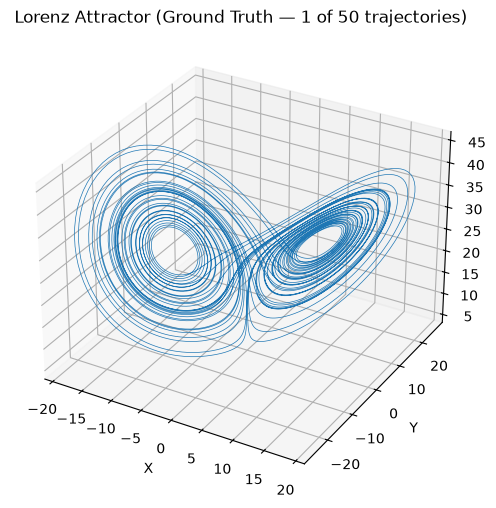

Total ground truth training samples: 500000 (50 trajectories x 10000 steps)


In [3]:
# Define the Lorenz system
def lorenz_system(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# --- Ensemble (multi-trajectory) settings ---
N_ENSEMBLE = 50          # number of trajectories per data source
T_SPINUP   = (0, 50)     # spin-up integration to reach the attractor
T_TRAIN    = (0, 50)     # length of each ensemble member trajectory
PERTURB    = 0.05        # size of random perturbation to initial conditions
N_EVAL     = 10000       # time steps per trajectory

# Step 1: spin up a single trajectory to get a point on the attractor
# The assumption is: after integrating for 50 time units, 
# the trajectory has settled onto the attractor, so the state at t=50 is 
# a good representative point on it. Then you perturb that single point by a small amount (±0.05) 
# to create 50 slightly different starting points, each of which will evolve along 
# a nearby trajectory still covering the attractor.
t_eval_spinup = np.linspace(T_SPINUP[0], T_SPINUP[1], N_EVAL)
sol_spinup = solve_ivp(lorenz_system, T_SPINUP, [1.0, 1.0, 1.0], t_eval=t_eval_spinup)
attractor_point = sol_spinup.y[:, -1]  # last solution is on the attractor

# Step 2: generate N_ENSEMBLE trajectories from perturbed initial conditions
# important for reproducibility : This reproducibility holds if you run the notebook from top to bottom. If
# you only run the ensemble cell in isolation (without re-running the seed setup), 
#you'll get different perturbations each time.
t_eval = np.linspace(T_TRAIN[0], T_TRAIN[1], N_EVAL)
gt_trajectories = []  # list of (x, y, z) arrays
for i in range(N_ENSEMBLE):
    perturb = np.random.uniform(-PERTURB, PERTURB, 3)
    ic = attractor_point + perturb
    sol = solve_ivp(lorenz_system, T_TRAIN, ic, t_eval=t_eval)
    gt_trajectories.append(sol.y)  # each element is shape (3, N_EVAL)

# Concatenate all trajectories for easy access
x_gt = np.concatenate([tr[0] for tr in gt_trajectories])
y_gt = np.concatenate([tr[1] for tr in gt_trajectories])
z_gt = np.concatenate([tr[2] for tr in gt_trajectories])

# Use the first trajectory for plotting (representative)
t = t_eval
x, y, z = gt_trajectories[0]

# Plot the first ground truth trajectory
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.5)
ax.set_title(f"Lorenz Attractor (Ground Truth — 1 of {N_ENSEMBLE} trajectories)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()
print(f"Total ground truth training samples: {len(x_gt)} ({N_ENSEMBLE} trajectories x {N_EVAL} steps)")

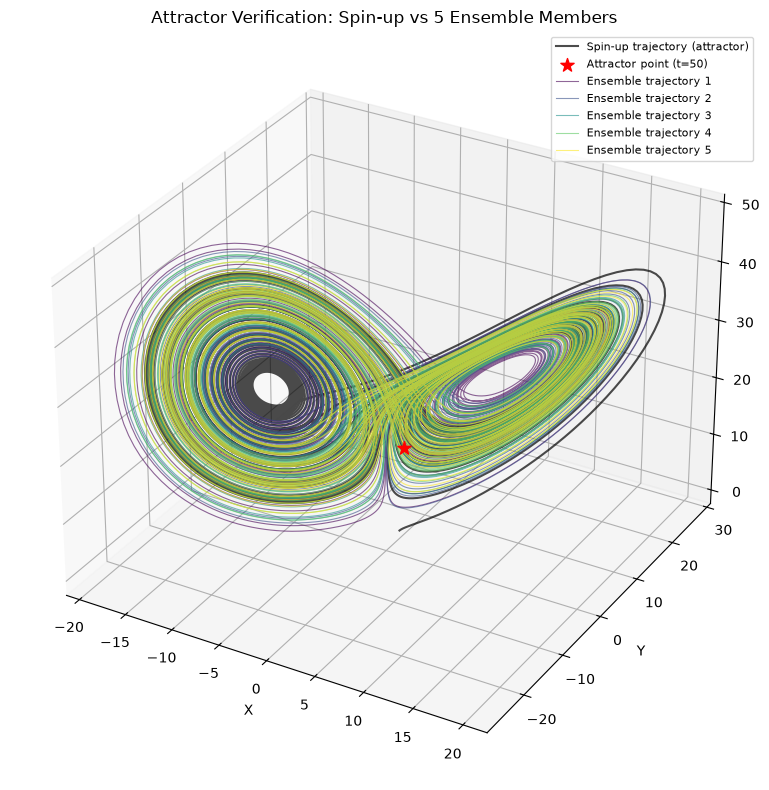

Red star marks attractor_point at t=50
Black line is the spin-up trajectory showing the full attractor
Colored lines show 5 of the 50 ensemble trajectories starting near the attractor point
All ensemble trajectories should stay close to the attractor structure.


In [4]:

# Verify attractor point and ensemble coverage
# Plot the spin-up trajectory (full attractor) and several ensemble trajectories together
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')

# Plot the spin-up trajectory in black — this shows the full attractor structure
ax.plot(sol_spinup.y[0], sol_spinup.y[1], sol_spinup.y[2], 'k-', lw=1.5, label='Spin-up trajectory (attractor)', alpha=0.7)

# Plot the attractor point as a large red dot
ax.scatter(*attractor_point, color='red', s=100, marker='*', label=f'Attractor point (t=50)', zorder=5)

# Plot the first 5 ensemble trajectories to show coverage
n_to_plot = min(5, N_ENSEMBLE)
colors = plt.cm.viridis(np.linspace(0, 1, n_to_plot))
for i in range(n_to_plot):
    ax.plot(gt_trajectories[i][0], gt_trajectories[i][1], gt_trajectories[i][2], 
            color=colors[i], lw=0.8, alpha=0.6, label=f'Ensemble trajectory {i+1}')

ax.set_title(f'Attractor Verification: Spin-up vs {n_to_plot} Ensemble Members')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Red star marks attractor_point at t=50")
print(f"Black line is the spin-up trajectory showing the full attractor")
print(f"Colored lines show {n_to_plot} of the {N_ENSEMBLE} ensemble trajectories starting near the attractor point")
print(f"All ensemble trajectories should stay close to the attractor structure.")


# 3. Create the Imperfect Numerical Model

Question 1 : How can we create an imperfect numerical model of the Lorenz system? 

Imperfect model can be created introducing parameter errors or reducing resolution. In this case we try using the parameters sigma=12.0, rho=25.0, beta=2.5 and observe the differences in the system's behavior.

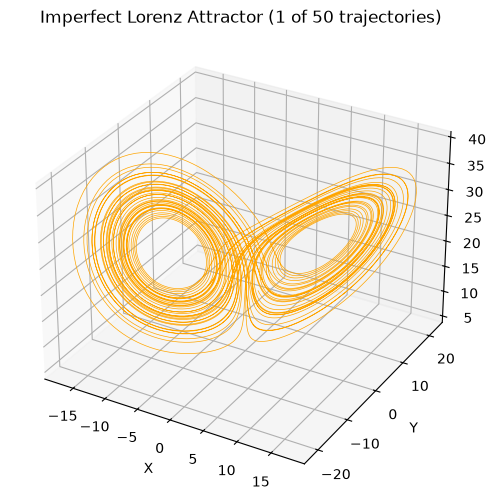

Total imperfect model training samples: 500000


In [5]:
# Define an imperfect Lorenz system with parameter errors
def imperfect_lorenz_system(t, state, sigma=12.0, rho=25.0, beta=2.5):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Generate N_ENSEMBLE imperfect trajectories from the same perturbed initial conditions
imp_trajectories = []
for i in range(N_ENSEMBLE):
    perturb = np.random.uniform(-PERTURB, PERTURB, 3)
    ic = attractor_point + perturb
    sol = solve_ivp(imperfect_lorenz_system, T_TRAIN, ic, t_eval=t_eval)
    imp_trajectories.append(sol.y)

# Concatenate all imperfect trajectories
x_imp_all = np.concatenate([tr[0] for tr in imp_trajectories])
y_imp_all = np.concatenate([tr[1] for tr in imp_trajectories])
z_imp_all = np.concatenate([tr[2] for tr in imp_trajectories])

# Use the first trajectory for plotting
x_imp, y_imp, z_imp = imp_trajectories[0]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x_imp, y_imp, z_imp, lw=0.5, color='orange')
ax.set_title(f"Imperfect Lorenz Attractor (1 of {N_ENSEMBLE} trajectories)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()
print(f"Total imperfect model training samples: {len(x_imp_all)}")

# 4. Generate Sparse and Noisy Observations

Question 2: How can we generate sparse and noisy observations from the ground truth data? 

Consider sampling the data sparsely and adding noise to mimic real-world measurement limitations. Think about the number of samples to take and the level of noise to introduce.

In the example proposed, a subset of the ground truth data is selected by randomly sampling 500 indices to create sparse observations. Then, Gaussian noise with a mean of 0 and a standard deviation of 2.0 was added to the x, y, and z coordinates of the sampled data points. This process simulates real-world scenarios where measurements are both limited and noisy.

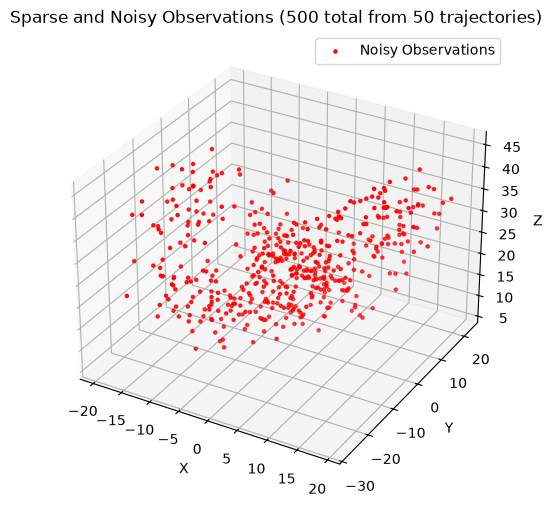

Total sparse observation samples: 500


In [9]:
# Generate sparse and noisy observations from each ground truth trajectory
# Each trajectory contributes a random subset of points with added Gaussian noise
num_samples_per_traj = 500 // N_ENSEMBLE  # spread observations across trajectories
noise_std = 2.0

x_sparse_list, y_sparse_list, z_sparse_list, t_sparse_list = [], [], [], []
for tr in gt_trajectories:
    x_tr, y_tr, z_tr = tr
    n = len(t_eval)
    idx = sorted(random.sample(range(n), num_samples_per_traj))
    x_sparse_list.append(x_tr[idx] + np.random.normal(0, noise_std, num_samples_per_traj))
    y_sparse_list.append(y_tr[idx] + np.random.normal(0, noise_std, num_samples_per_traj))
    z_sparse_list.append(z_tr[idx] + np.random.normal(0, noise_std, num_samples_per_traj))
    t_sparse_list.append(t_eval[idx])

x_sparse = np.concatenate(x_sparse_list)
y_sparse = np.concatenate(y_sparse_list)
z_sparse = np.concatenate(z_sparse_list)
t_sparse = np.concatenate(t_sparse_list)

# Plot the sparse observations
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(x_sparse, y_sparse, z_sparse, c='red', s=5, label='Noisy Observations')
ax.set_title(f"Sparse and Noisy Observations ({len(x_sparse)} total from {N_ENSEMBLE} trajectories)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()
print(f"Total sparse observation samples: {len(x_sparse)}")

# 5. Build Emulator of the  Lorenz System

Question 3: How can we build and train machine learning models to predict the Lorenz system?

Try using different data sources such as ground truth, sparse observations, imperfect numerical model outputs, or a combination of the sources. Consider how to define the model architecture, preprocess the data, and evaluate the model's performance.

The Lorenz system generates sequential data with temporal dependencies. This notebook supports both an LSTM and a simple dense neural network so the user can choose which one to train. However for the workshop we will use the "dense" architecture because it is quicker to run. It may take too long to run the LSTM during the workshop. If you are curious and want to give it a go in your own time, there is another notebook in the repository,lorenz_ensamble_with_benchmarking.ipynb where dense and lstm are benchmarked .

In [6]:
# Import additional libraries for data preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Define the model builder
# The dense option mirrors the simple feed-forward network in utilities.py
# and uses only the last state in each sequence as input.
def build_model(model_architecture, sequence_length, cc_activation='tanh'):
    from tensorflow.keras import Input
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense

    if model_architecture == 'lstm':
        input_shape = (sequence_length, 3)
        model = Sequential([
            Input(shape=input_shape),
            LSTM(64, activation=cc_activation, return_sequences=True),
            LSTM(64, activation=cc_activation),
            Dense(3)  # Predict x, y, z
        ])
        cc_in_typ_mod = 'Sequence'
    elif model_architecture == 'dense':
        input_shape = (3,)
        model = Sequential([
            Input(shape=input_shape),
            Dense(8, activation=cc_activation),
            Dense(16, activation=cc_activation),
            Dense(8, activation=cc_activation),
            Dense(3)  # Predict x, y, z
        ])
        cc_in_typ_mod = 'Vector'
    else:
        raise ValueError("model_architecture must be 'lstm' or 'dense'")

    model.compile(optimizer='adam', loss='mse')
    return model, cc_in_typ_mod


# Helper function to create sequences for time-series prediction (LSTM only)
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)


# Helper function to create single states for Dense NN models
# Each sample is just a single state paired with the next state
def create_dense_inputs(data):
    X, y = [], []
    for i in range(len(data) - 1):
        X.append(data[i])                     # single state vector
        y.append(data[i + 1])                 # next state vector
    return np.array(X), np.array(y)

In [7]:
# Define sequence_length for LSTM models (ONLY used when model_architecture == 'lstm')
# For Dense models, single states are used instead, so sequence_length is ignored
sequence_length = 50

# 5.1 Preprocessing : Normalize the data
Normalization ensures that all features are on a similar scale, improving model training and convergence.
It also prevents features with larger scales from dominating the learning process.

## Important: Scaler is Fixed Across All Data Sources

To ensure fair comparison between models, we **fit the scaler once** on the ground truth ensemble, then **reuse the same scaler** for imperfect model and observations. This is critical because:

- All models see data on the same normalized scale
- The scaler parameters (min/max from ground truth) are fixed for the entire analysis
- Prevents information leakage (test set scaling is not influenced by training data)


In [10]:
# Fit scaler on the full ground truth ensemble, then apply to all sources
scaler = MinMaxScaler()
ground_truth_scaled = scaler.fit_transform(np.column_stack((x_gt, y_gt, z_gt)))
imperfect_scaled    = scaler.transform(np.column_stack((x_imp_all, y_imp_all, z_imp_all)))
observations_scaled = scaler.transform(np.column_stack((x_sparse, y_sparse, z_sparse)))
print(f"ground_truth_scaled shape: {ground_truth_scaled.shape}")
print(f"imperfect_scaled shape:    {imperfect_scaled.shape}")
print(f"observations_scaled shape: {observations_scaled.shape}")

ground_truth_scaled shape: (500000, 3)
imperfect_scaled shape:    (500000, 3)
observations_scaled shape: (500, 3)


In [11]:

# Verify scaler is fixed and document its parameters
print("=" * 60)
print("SCALER VERIFICATION (fixed across all data sources)")
print("=" * 60)
print(f"Scaler type: {type(scaler)}")
print(f"Scaler fitted on ground truth ensemble ({len(x_gt)} samples)")
print(f"Scaler will be REUSED (not refitted) for imperfect & observations")
print(f"\nScaler parameters (learned from ground truth):")
print(f"  Data min (X): {scaler.data_min_}")
print(f"  Data max (X): {scaler.data_max_}")
print(f"  Feature range: {scaler.feature_range}")
print(f"\nAll subsequent normalized datasets use this fixed scaler.")
print("=" * 60)


SCALER VERIFICATION (fixed across all data sources)
Scaler type: <class 'sklearn.preprocessing._data.MinMaxScaler'>
Scaler fitted on ground truth ensemble (500000 samples)
Scaler will be REUSED (not refitted) for imperfect & observations

Scaler parameters (learned from ground truth):
  Data min (X): [-18.98429696 -26.04496237   2.52061058]
  Data max (X): [19.11972257 26.30942865 46.96547742]
  Feature range: (0, 1)

All subsequent normalized datasets use this fixed scaler.


# 5.2 Split the data in training, validation, and test sets

Create a function that splits the data into training (70%) validation (15%) and test (15%)

In [12]:
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
def split_data(X, y, train_ratio=0.7, val_ratio=0.15):
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)
    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
    X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)



# 5.3  Emulator Training

Steps:

1. define the architecture
2. Use that selected architecture for the emulators based on:
   - ground truth
   - observations only
   - imperfect model + sparse observations

In [14]:
model_architecture='dense'

In [15]:
# Emulator based on ground truth
print(f"Using selected architecture: {model_architecture}")
if model_architecture == 'lstm':
    X_gt, y_gt = create_sequences(ground_truth_scaled, sequence_length)
else:  # dense
    X_gt, y_gt = create_dense_inputs(ground_truth_scaled)

(X_gt_train, y_gt_train), (X_gt_val, y_gt_val), (X_gt_test, y_gt_test) = split_data(X_gt, y_gt)
print(f"Ground truth training samples: {len(X_gt_train)}")
print(f"Training ground truth-only emulator with architecture: {model_architecture}")
model_gt, cc_in_typ_mod = build_model(model_architecture, sequence_length)
history_gt = model_gt.fit(
    X_gt_train, y_gt_train,
    validation_data=(X_gt_val, y_gt_val),
    epochs=20, batch_size=32, verbose=1
)

Using selected architecture: dense
Ground truth training samples: 349999
Training ground truth-only emulator with architecture: dense
Epoch 1/20


E0000 00:00:1782396562.793789 1840958 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10914/10938 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0097

E0000 00:00:1782396580.882090 1840958 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10938/10938 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.0017 - val_loss: 8.2592e-06
Epoch 2/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 9.4869e-06 - val_loss: 6.5637e-06
Epoch 3/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 8.7337e-06 - val_loss: 6.1237e-06
Epoch 4/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 8.4259e-06 - val_loss: 5.8858e-06
Epoch 5/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 8.2305e-06 - val_loss: 5.7153e-06
Epoch 6/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step - loss: 8.0679e-06 - val_loss: 5.5898e-06
Epoch 7/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 7.9306e-06 - val_loss: 5.4855e-06
Epoch 8/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 7.8063e-06 - val_loss: 5.3896e-06
Epoch 9/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 7.6891e-06 - val_loss: 5.2968e-06
Epoch 10/20
10938/10938 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 7.5792e-06 - val_loss: 5.2065e-06
Epoch 11/20
10938/10938 

In [16]:
# Model based on observations only 

print(f"Using selected architecture: {model_architecture}")
if model_architecture == 'lstm':
    X_obs, y_obs = create_sequences(observations_scaled, sequence_length)
else:  # dense
    X_obs, y_obs = create_dense_inputs(observations_scaled)

(X_obs_train, y_obs_train), (X_obs_val, y_obs_val), (X_obs_test, y_obs_test) = split_data(X_obs, y_obs)
print(f"Observations training samples: {len(X_obs_train)}")
print(f"Training observations-only emulator with architecture: {model_architecture}")
model_obs, cc_in_typ_mod = build_model(model_architecture, sequence_length)
history_obs = model_obs.fit(
    X_obs_train, y_obs_train,
    validation_data=(X_obs_val, y_obs_val),
    epochs=20, batch_size=32, verbose=1
)

Using selected architecture: dense
Observations training samples: 349
Training observations-only emulator with architecture: dense
Epoch 1/20


E0000 00:00:1782398985.214242 1840958 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5673 - val_loss: 0.3983
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2819 - val_loss: 0.1841
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1269 - val_loss: 0.0799
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0621 - val_loss: 0.0464
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0475 - val_loss: 0.0425
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0471 - val_loss: 0.0421
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0465 - val_loss: 0.0412
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0457 - val_loss: 0.0408
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0453 - val_loss: 0.0408
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0451 - val_loss: 0.0406
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0448 - val_loss: 0.0404
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0446 - val_loss: 0.0402

In [17]:
# Model based on imperfect ensemble + sparse observations ensemble using selected architecture
print(f"Using selected architecture: {model_architecture}")
if model_architecture == 'lstm':
    X_imperfect, y_imperfect = create_sequences(imperfect_scaled, sequence_length)
    X_obs, y_obs = create_sequences(observations_scaled, sequence_length)
else:  # dense
    X_imperfect, y_imperfect = create_dense_inputs(imperfect_scaled)
    X_obs, y_obs = create_dense_inputs(observations_scaled)

X_combined_obs_num = np.concatenate((X_imperfect, X_obs), axis=0)
y_combined_obs_num = np.concatenate((y_imperfect, y_obs), axis=0)

(X_combined_obs_num_train, y_combined_obs_num_train), (X_combined_obs_num_val, y_combined_obs_num_val), (X_combined_obs_num_test, y_combined_obs_num_test) = split_data(X_combined_obs_num, y_combined_obs_num)
print(f"Combined (imperfect + obs) training samples: {len(X_combined_obs_num_train)}")
print(f"Training combined (imperfect + obs) emulator with architecture: {model_architecture}")
model_combined_obs_num, cc_in_typ_mod = build_model(model_architecture, sequence_length)
history_combined_obs_num = model_combined_obs_num.fit(
    X_combined_obs_num_train, y_combined_obs_num_train,
    validation_data=(X_combined_obs_num_val, y_combined_obs_num_val),
    epochs=20, batch_size=32, verbose=1
)

Using selected architecture: dense
Combined (imperfect + obs) training samples: 350348
Training combined (imperfect + obs) emulator with architecture: dense
Epoch 1/20


E0000 00:00:1782399003.767294 1840958 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10929/10949 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025

E0000 00:00:1782399022.403262 1840958 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


10949/10949 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 4.7486e-04 - val_loss: 9.7615e-06
Epoch 2/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 7.7968e-06 - val_loss: 5.1962e-06
Epoch 3/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 6.7525e-06 - val_loss: 4.9257e-06
Epoch 4/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 6.6035e-06 - val_loss: 4.8202e-06
Epoch 5/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 6.4774e-06 - val_loss: 4.7382e-06
Epoch 6/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 6.3698e-06 - val_loss: 4.6561e-06
Epoch 7/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 6.2829e-06 - val_loss: 4.5971e-06
Epoch 8/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 6.2135e-06 - val_loss: 4.5687e-06
Epoch 9/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 6.1580e-06 - val_loss: 4.5470e-06
Epoch 10/20
10949/10949 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 6.1102e-06 - val_loss: 4.5200e-06
Epoch 11/20
10949/10

# 6. Analyse Training and Validation Loss Curves

This section analyse the three downstream emulators trained with the selected architecture.

Question: how do training and validation losses evolve, and what do they tell us about fit and generalization?

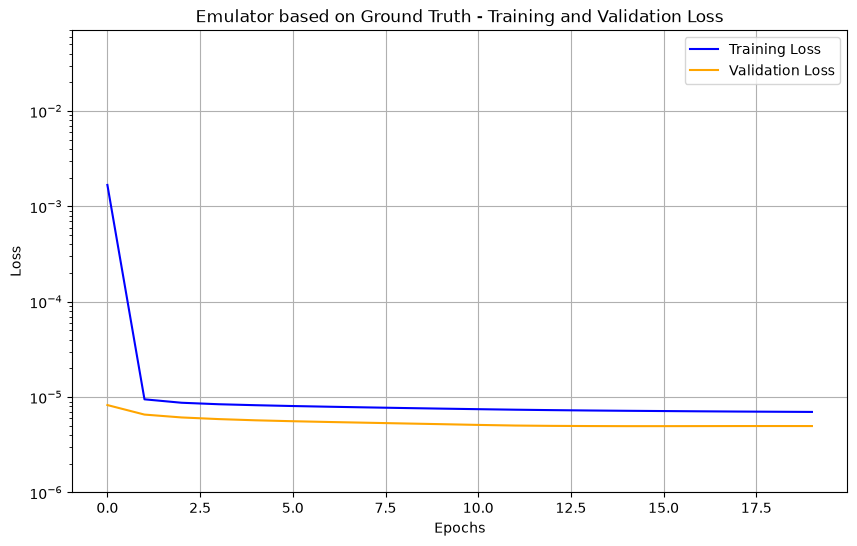

In [18]:
# Plot the loss function for the emulator of ground truth
plt.figure(figsize=(10, 6))
plt.plot(history_gt.history['loss'], label='Training Loss', color='blue')
plt.plot(history_gt.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Emulator based on Ground Truth - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

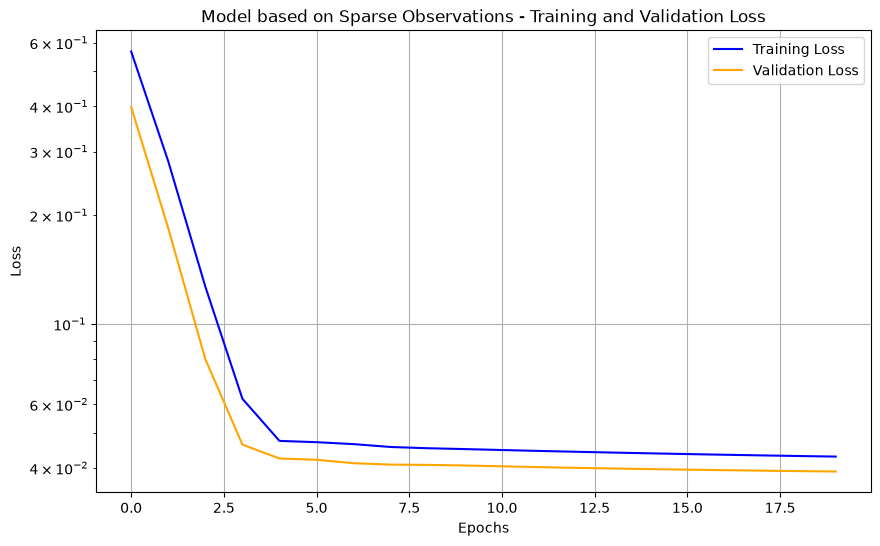

In [24]:
# Plot the loss function for the model trained on sparse observations
plt.figure(figsize=(10, 6))
plt.plot(history_obs.history['loss'], label='Training Loss', color='blue')
plt.plot(history_obs.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model based on Sparse Observations - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
#plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

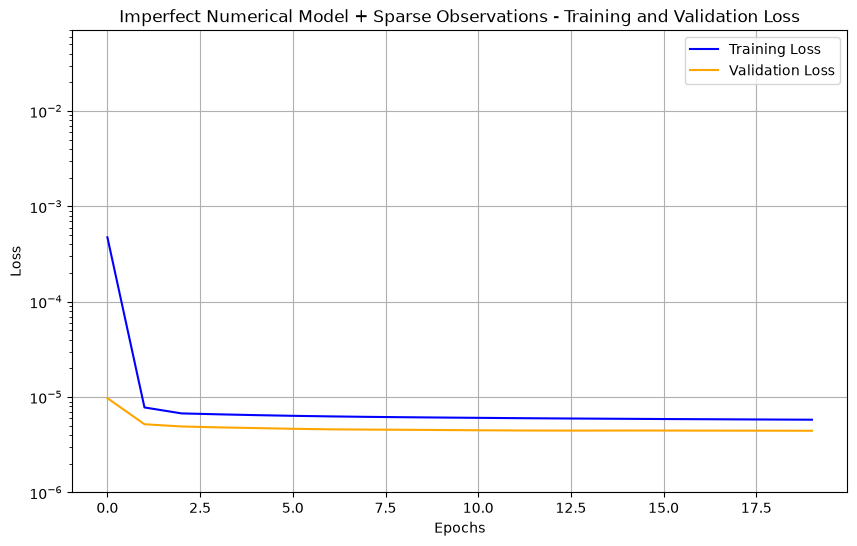

In [20]:
# Plot the loss function for the model trained on imperfect numerical model and sparse observations
plt.figure(figsize=(10, 6))
plt.plot(history_combined_obs_num.history['loss'], label='Training Loss', color='blue')
plt.plot(history_combined_obs_num.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Imperfect Numerical Model + Sparse Observations - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

Downstream emulator behavior:
- Observations-only emulator typically learns more slowly because inputs are sparse and noisy. After 20 epochs it is still converging. Both curves are still declining at epoch 20 with no sign of flattening. More epochs would likely improve the model further.
- The imperfect-model + observations emulator usually converges faster and generalizes better because it combines physics-based and observational information.
- The validation-loss curves are the main diagnostic for overfitting: if validation rises while training keeps dropping, overfitting is likely.

In [22]:
history_obs.history['val_loss']



[0.3982686400413513,
 0.1840793788433075,
 0.07994699478149414,
 0.04639505222439766,
 0.04245584458112717,
 0.04210720583796501,
 0.04120148718357086,
 0.04084046930074692,
 0.0407642237842083,
 0.04060748964548111,
 0.04039483517408371,
 0.040189217776060104,
 0.04000454396009445,
 0.03983841463923454,
 0.03968595340847969,
 0.03954417631030083,
 0.039412904530763626,
 0.03929275646805763,
 0.03918348625302315,
 0.039084289222955704]

In [23]:
history_obs.history['loss']

[0.5672709941864014,
 0.2818657159805298,
 0.12688517570495605,
 0.062110815197229385,
 0.047488823533058167,
 0.047107260674238205,
 0.04652882367372513,
 0.045686230063438416,
 0.04532401263713837,
 0.045082513242959976,
 0.044812873005867004,
 0.04455476999282837,
 0.04431529715657234,
 0.04408908635377884,
 0.04387648403644562,
 0.0436757355928421,
 0.04348521679639816,
 0.043305154889822006,
 0.04313578084111214,
 0.042976826429367065]

# Evaluate All Models on a Common Test Dataset

Question 5: Can we use the models to make a prediction on unseen data ?  We will use the models to predict unseen data from the test dataset. To ensure a fair comparison,we create a common test dataset derived only from the test portion of the ground truth data, avoiding overlap with training and validation data.

In [34]:
# Split the ground truth data into training, validation, and test sets
(X_ground_truth_train, y_ground_truth_train), \
(X_ground_truth_val, y_ground_truth_val), \
(X_ground_truth_test, y_ground_truth_test) = split_data(ground_truth_scaled, ground_truth_scaled, train_ratio=0.7, val_ratio=0.15)

# Create sequences for the test set based on model architecture
if model_architecture == 'lstm':
    X_common_test, y_common_test = create_sequences(X_ground_truth_test, sequence_length)
else:  # dense
    X_common_test, y_common_test = create_dense_inputs(X_ground_truth_test)

In [35]:
# Generate predictions for the common test dataset
y_pred_obs = model_obs.predict(X_common_test, verbose=0)
y_pred_combined_obs_num = model_combined_obs_num.predict(X_common_test, verbose=0)

E0000 00:00:1782404233.089275 1840958 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


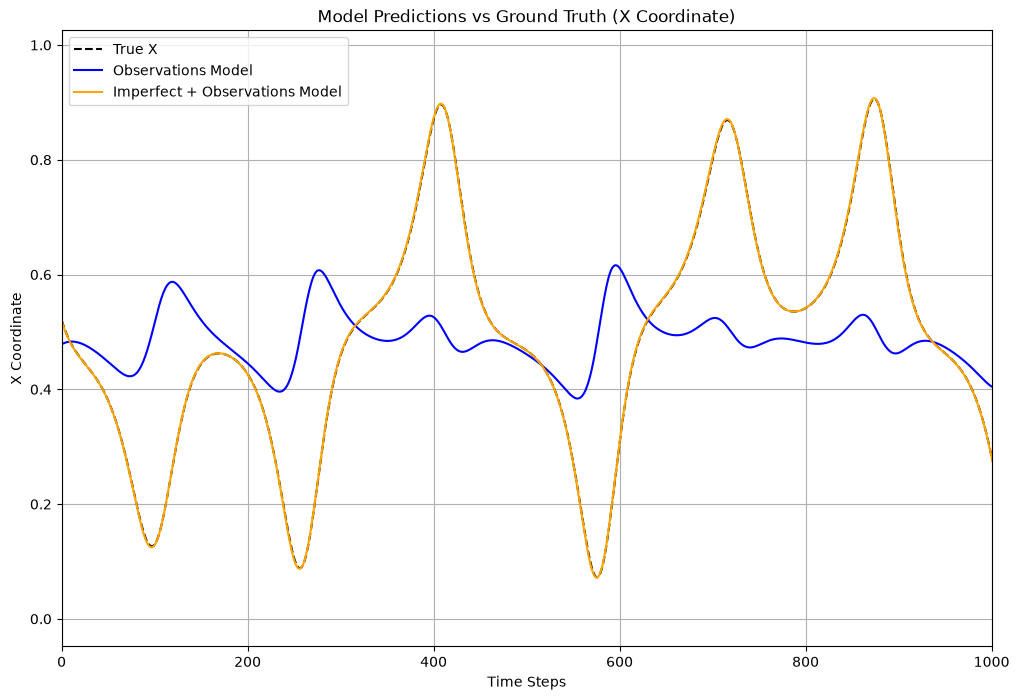

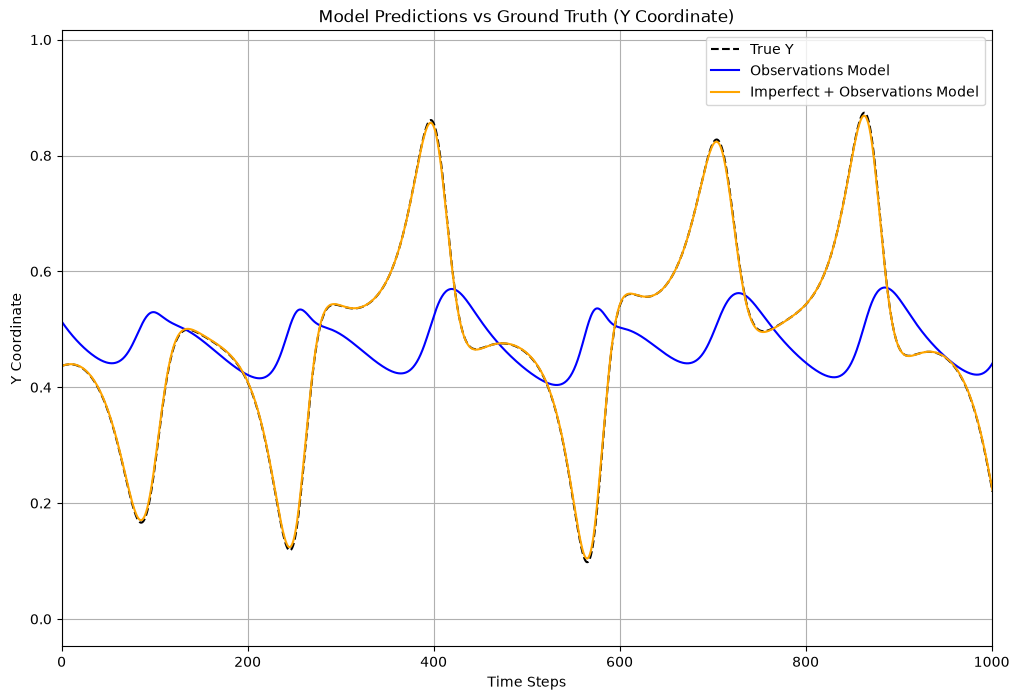

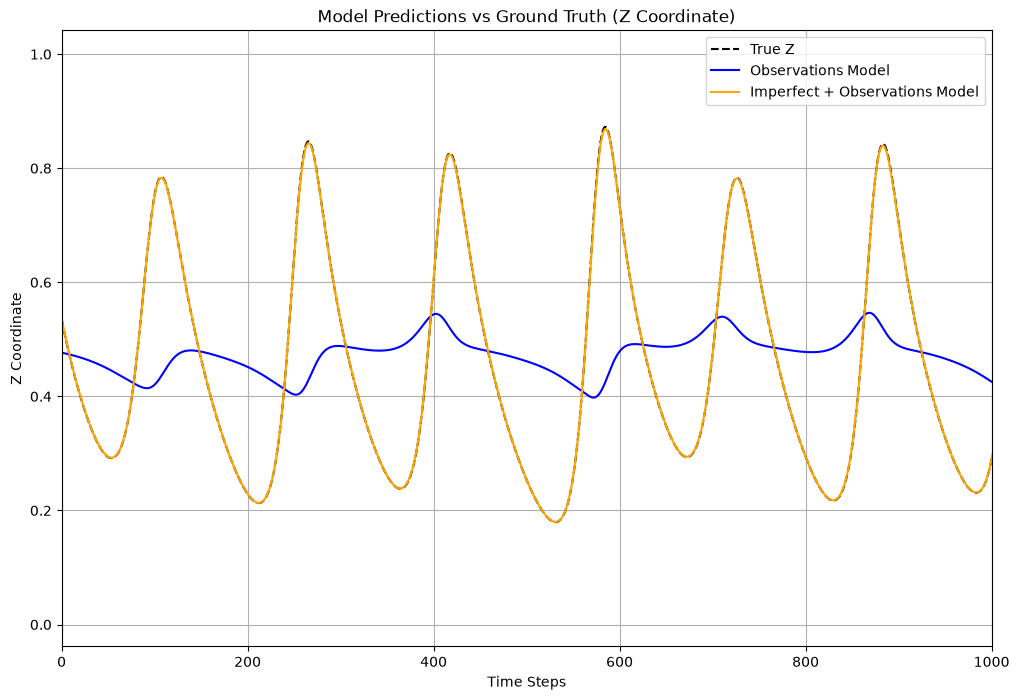

In [36]:


# Visualize predictions vs ground truth for the common test dataset (X Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 0], label='True X', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 0], label='Observations Model', color='blue')
plt.plot(y_pred_combined_obs_num[:, 0], label='Imperfect + Observations Model', color='orange')

plt.title('Model Predictions vs Ground Truth (X Coordinate)')
plt.xlabel('Time Steps')
plt.ylabel('X Coordinate')
plt.xlim(0, 1000)
plt.legend()
plt.grid(True)
plt.show()

# Visualize predictions vs ground truth for the common test dataset (Y Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 1], label='True Y', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 1], label='Observations Model', color='blue')
plt.plot(y_pred_combined_obs_num[:, 1], label='Imperfect + Observations Model', color='orange')

plt.title('Model Predictions vs Ground Truth (Y Coordinate)')
plt.xlabel('Time Steps')
plt.xlim(0, 1000)
plt.ylabel('Y Coordinate')

plt.legend()
plt.grid(True)
plt.show()

# Visualize predictions vs ground truth for the common test dataset (Z Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 2], label='True Z', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 2], label='Observations Model', color='blue')
plt.plot(y_pred_combined_obs_num[:, 2], label='Imperfect + Observations Model', color='orange')

plt.title('Model Predictions vs Ground Truth (Z Coordinate)')
plt.xlabel('Time Steps')
plt.xlim(0, 1000)
plt.ylabel('Z Coordinate')

plt.legend()
plt.grid(True)

plt.show()

# Considerations

## Observations-only model:
- Trained on only 500 sparse, noisy points spread across 50 trajectories (~10 observations per trajectory)
- The noise level (std=2.0) drowns out the signal
- The model has almost no information to learn the true Lorenz dynamics from
- **Result:** poor performance, high residual loss (~0.04)

## Imperfect+observations model:
- Trained on ~500,500 total samples:
  - Imperfect model: 50 trajectories × 10,000 steps = 500,000 points
  - Observations: 500 points
- The imperfect model (with wrong parameters) still captures the basic structure of chaotic dynamics—the phase space geometry, the attractor shape
- The observations act as calibration/correction signals—they guide the model to adjust the imperfect physics
- Combined, they provide:
  - Rich structural information from the imperfect model
  - Ground-truth correction from observations
  - Orders of magnitude more training data

## Key insight:
The imperfect model + observations combination works because the two data sources are complementary:
- **Imperfect model:** good structure, wrong details
- **Observations:** good truth, sparse/noisy


# What we learned:

- **Simulating Chaotic Systems:** The Lorenz system demonstrates how to generate synthetic data for chaotic environments.
- **Data Preprocessing:** Normalization and scaling of data are essential for improving model training and convergence.
- **Dataset Splitting:** Splitting data into training, validation, and test sets ensures fair evaluation and prevent data leakage.
- **Combining Data Sources:** Using diverse data sources, such as ground truth, sparse observations, and imperfect numerical models, to build different models.
- **Evaluating Loss Functions:** Analysing training and validation loss curves helps in understanding model performance.
- **Make predictions on unseen data:** The test data can be used to make predictions on unseen data.


# Limitations

For this notebook, we chose the **dense neural network architecture** because it trains much faster than LSTM, making it practical for workshop and demonstration settings. The dense model processes individual state vectors (not sequences) and relies on learning the one-step dynamics.

**Test Dataset Note:** The test dataset is created by concatenating test portions from all 50 ensemble trajectories end-to-end into a single array. When `create_dense_inputs` generates state→next-state pairs, it can spuriously pair the final state of one trajectory with the initial state of the next trajectory—these are physically unrelated points. While this affects only a small fraction of the test set (roughly one spurious boundary pair per trajectory, or ~50 out of tens of thousands of pairs), it is worth noting if fine-grained evaluation is required. For stricter validation, one could split the test set per-trajectory.

This notebook is intended as a demonstration of combining diverse data sources to improve machine learning predictions in chaotic systems. The focus is on illustrating the methodology rather than achieving state-of-the-art performance.


References:
1. Lorenz, E. N. (1963). Deterministic nonperiodic flow. Journal of the Atmospheric Sciences, 20(2), 130-141.


    